## Performing Comparative Segmentation Analysis
**In this notebook a comparison will be made between Otsu Thresholding and K-means clustering (k=3).**

The image To be analysed is taken from Aditya L1's onboard SUIT. The image is taken on 09-05-2026 at 07:09:21 AM using the NB03 filter.

We have already applied Otsu thresholding in part 1 of our project, so we will be directly using those results in this notebook.

**Importing necessary libraries:**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')
import sunpy.map

from suitcolormap import suit_cmap, suit_norm
from sklearn.cluster import KMeans
from skimage.measure import label
from skimage.measure import regionprops
from sunpy.net import attrs as a
from sunpy.net import Fido
from skimage import measure
import astropy.units as u
from sunpy.coordinates import HeliographicStonyhurst


**Importing the image:**

In [2]:
suit_map = sunpy.map.Map(r"..\Data\Raw\SUT_T26_0649_002132_Lev1.0_2026-05-09T07.09.21.400_08B2NB03.fits")

## Applying K-means clustering
**We are using the same array (arr_2d_masked)- on which Otsu thresholding was done- for K-means clustering so that we can do a valid comparison.**

In [3]:
arr_2d_masked = np.load(r"..\Data\Processed\arr_2d_masked.npy")  # This is the same array on which otsu thresholding was done.

Applying the much needed operation on the array to get the ideal form **(n_samples, n_features)** for performing K-means clustering.

In [4]:
arr_1d_masked = arr_2d_masked.flatten() 
print(arr_1d_masked.shape)
arr_1d_masked = arr_1d_masked.reshape(-1,1)   # (1494304,1)

# Creating kMeans object:
kmeans = KMeans(n_clusters=3, init='k-means++',n_init=10, random_state=42)
kmeans.fit(arr_1d_masked)

(4194304,)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float32](3, 1)","[[0.4

**k-means clustering has identified 3 cluster centers-**

**1.** 0- This represents the black off-disk background in the image. **[label = 0]**

**2.** 0.47- This is the quiet sun  which comprises a major portion of solar disk's area. **[label = 1]**

**3.** 0.63- It represents the brightest features in the image which include active regions, solar limb and off-disk distortion. This value,**0.63** is significantly higher than that pinned by Otsu which was **0.5341**. This difference has a direct consequence in the detection of active regions as will be discussed later in detail. **[label = 2]**

In [5]:
kmeans.labels_     # This is a 1D array and it can't be used to generate image, we need to reshape it.
kmeans.labels_ = kmeans.labels_.reshape((2048,2048))

**Generating raw K-means clustered image-**

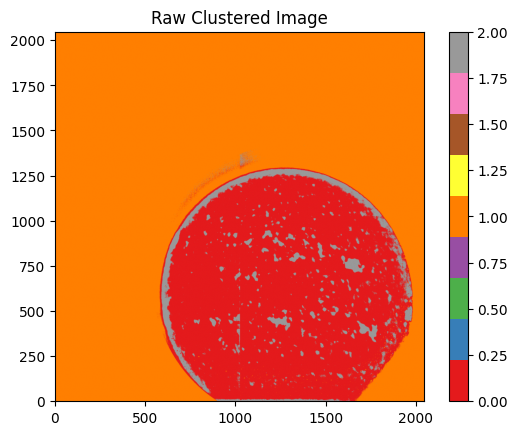

In [6]:
plt.imshow(kmeans.labels_, cmap = 'Set1', origin='lower')
plt.colorbar()
plt.title('Raw Clustered Image')
plt.savefig(r'../Outputs/Figures/Part_2c/Fig.1_Raw_Clustered_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**As can be seen from the image, it has 3 different colors which corresponding to different regions-**

**1.** Grey region represents the brightest regions in the image (active regions + solar limb + off-disk distortions).

**2.** Red region represents quiet sun which occupies majority of the area of solar disk.

**3.** Orange region is  the black background.

**Separating the active-region area-**

The array which containing active region pixels is **bright_cluster_mask**

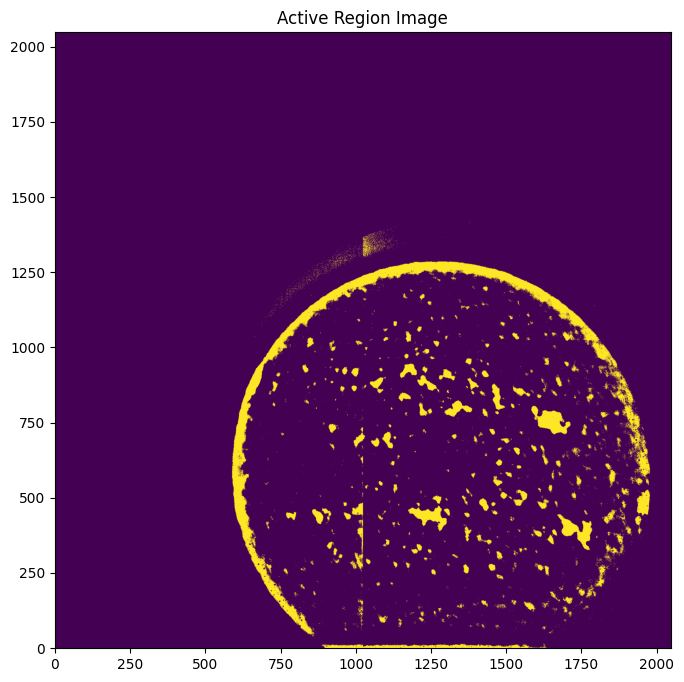

In [7]:
bright_cluster_mask = (kmeans.labels_ == 2)   #Separating the active region area
plt.figure(figsize=(8,8))
plt.imshow(bright_cluster_mask, origin='lower')
plt.title('Active Region Image')
plt.savefig(r'../Outputs/Figures/Part_2c/Fig.2_Active_Region_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**Before we compare Otsu thresholding and K-means clustering we would have to perform morphological operations just as we did in part 1 of our project. This ensures we get an image which is less prone to errors thus enabling a valid comparison.**

## Applying Morphological Operations :

[np.float64(81446.0), np.float64(6194.0), np.float64(6050.0), np.float64(5234.0), np.float64(4489.0), np.float64(2635.0), np.float64(2197.0), np.float64(1725.0), np.float64(1441.0), np.float64(1415.0), np.float64(1414.0), np.float64(1091.0), np.float64(1090.0), np.float64(1043.0), np.float64(1042.0), np.float64(1017.0), np.float64(976.0), np.float64(946.0), np.float64(892.0), np.float64(885.0), np.float64(853.0), np.float64(807.0), np.float64(807.0), np.float64(790.0), np.float64(751.0), np.float64(689.0), np.float64(615.0), np.float64(607.0), np.float64(601.0), np.float64(565.0), np.float64(554.0), np.float64(532.0), np.float64(515.0), np.float64(511.0), np.float64(509.0), np.float64(494.0), np.float64(493.0), np.float64(481.0), np.float64(460.0), np.float64(447.0), np.float64(446.0), np.float64(425.0), np.float64(422.0), np.float64(398.0), np.float64(394.0), np.float64(387.0), np.float64(387.0), np.float64(383.0), np.float64(376.0), np.float64(371.0), np.float64(360.0), np.float64(35

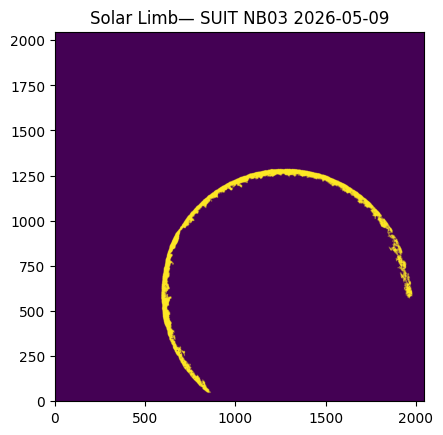

In [8]:
labeled = label(bright_cluster_mask)  #labeled array.
labeled_regions = regionprops(labeled)  #Regionprops is a function that measures a region's properties like label number, area, coordinates, etc. 
lst = []                                # We will store in list the areas of labelled regions in descending order to identify limb. 
for i in range(0,len(labeled_regions)):
    lst.append(labeled_regions[i].area)
lst.sort(reverse= True)
print(lst)

for i in range(0, len(labeled_regions)):
    if (labeled_regions[i].area == 81446):   #Trying to identify the limb by enterring the area manually.
        p = (labeled_regions[i].label)

test_label = (labeled == p)            # Verifying if the label found corresponds to the limb or not. 
plt.imshow(test_label, origin='lower')
plt.title('Solar Limb— SUIT NB03 2026-05-09')
plt.savefig(r'../Outputs/Figures/Fig.6_Solar_Limb_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**Successfully identified solar limb label = 50**

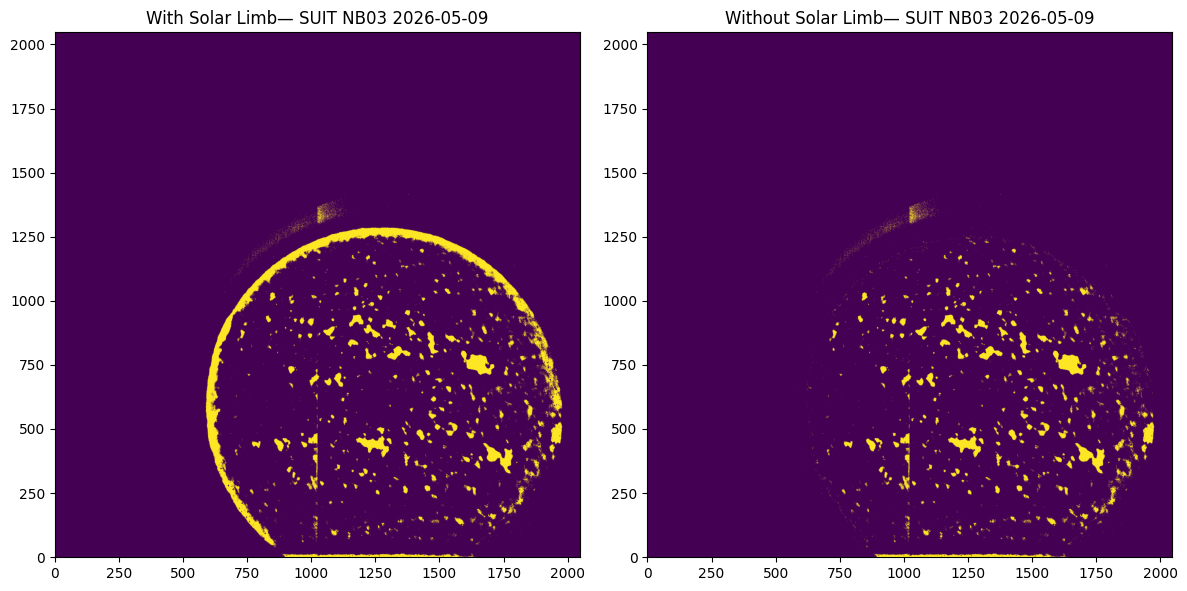

In [9]:
# Area: 81446, 6194, 6050, 5234, 4489, 2635, 2197
bad_labels = [50]
updated_labels = np.isin(labeled, bad_labels)
'''Although we know that there is only one label above area 10000 still I have shown the approach that can be followed to identify bad labels with 
sufficient regard to any modification in area. '''
solar_limb_removed = (bright_cluster_mask) & (~updated_labels)   # Array not having bad labels.

# Comparing old and new image side by side to see the visible change: 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(bright_cluster_mask, origin='lower')
ax[0].set_title('With Solar Limb— SUIT NB03 2026-05-09')
ax[1].imshow(solar_limb_removed, origin='lower')
ax[1].set_title('Without Solar Limb— SUIT NB03 2026-05-09')
plt.tight_layout()
plt.show()

**We have successfully removed solar limb.**
## Removing Horizontal and Vertical Patches on-disk 

[np.float64(6194.0), np.float64(6050.0), np.float64(5234.0), np.float64(4489.0), np.float64(2635.0), np.float64(2197.0), np.float64(1725.0), np.float64(1441.0), np.float64(1415.0), np.float64(1414.0), np.float64(1091.0), np.float64(1090.0), np.float64(1043.0), np.float64(1042.0), np.float64(1017.0), np.float64(976.0), np.float64(946.0), np.float64(892.0), np.float64(885.0), np.float64(853.0), np.float64(807.0), np.float64(807.0), np.float64(790.0), np.float64(751.0), np.float64(689.0), np.float64(615.0), np.float64(607.0), np.float64(601.0), np.float64(565.0), np.float64(554.0), np.float64(532.0), np.float64(515.0), np.float64(511.0), np.float64(509.0), np.float64(494.0), np.float64(493.0), np.float64(481.0), np.float64(460.0), np.float64(447.0), np.float64(446.0), np.float64(425.0), np.float64(422.0), np.float64(398.0), np.float64(394.0), np.float64(387.0), np.float64(387.0), np.float64(383.0), np.float64(376.0), np.float64(371.0), np.float64(360.0), np.float64(359.0), np.float64(349.

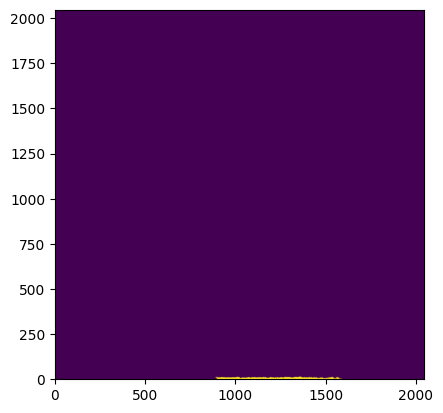

In [10]:
labeled_2 = label(solar_limb_removed)
labeled_2_regions = regionprops(labeled_2)
lst2 = []
for i in range(0, len(labeled_2_regions)):
               lst2.append(labeled_2_regions[i].area)
lst2.sort(reverse=True)
print(lst2)

for i in range(0, len(labeled_2_regions)):
        if (labeled_2_regions[i].area == 6194):
                p = labeled_2_regions[i].label
test_label_2 = (labeled_2 == p)
plt.imshow(test_label_2, origin='lower')
plt.show()

**Successfully identified horizontal patch**

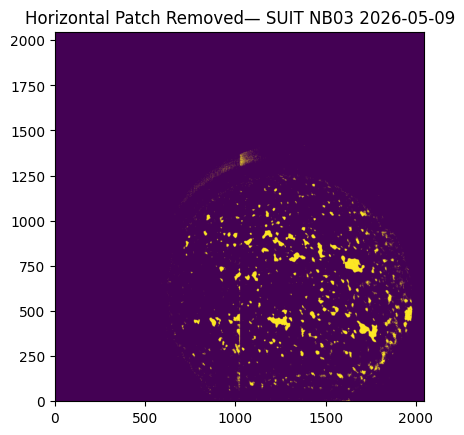

In [11]:
hor_blob_mask = (labeled_2==p)  #masking the horizontal blob that is to be removed.

hor_blob_removed = (solar_limb_removed) & (~hor_blob_mask)  # creating a new array which doesn't have the horizontal blob.
plt.imshow(hor_blob_removed, origin='lower')
plt.title('Horizontal Patch Removed— SUIT NB03 2026-05-09')
plt.show()

**Successfully removed horizontal patch, now we move on to find vertical patch**

[np.float64(6194.0), np.float64(6050.0), np.float64(5234.0), np.float64(4489.0), np.float64(2635.0), np.float64(2197.0), np.float64(1725.0), np.float64(1441.0), np.float64(1415.0), np.float64(1414.0), np.float64(1091.0), np.float64(1090.0), np.float64(1043.0), np.float64(1042.0), np.float64(1017.0), np.float64(976.0), np.float64(946.0), np.float64(892.0), np.float64(885.0), np.float64(853.0), np.float64(807.0), np.float64(807.0), np.float64(790.0), np.float64(751.0), np.float64(689.0), np.float64(615.0), np.float64(607.0), np.float64(601.0), np.float64(565.0), np.float64(554.0), np.float64(532.0), np.float64(515.0), np.float64(511.0), np.float64(509.0), np.float64(494.0), np.float64(493.0), np.float64(481.0), np.float64(460.0), np.float64(447.0), np.float64(446.0), np.float64(425.0), np.float64(422.0), np.float64(398.0), np.float64(394.0), np.float64(387.0), np.float64(387.0), np.float64(383.0), np.float64(376.0), np.float64(371.0), np.float64(360.0), np.float64(359.0), np.float64(349.

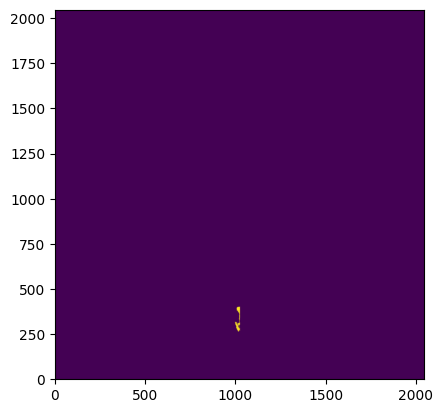

In [12]:
# Area: 81446, 6194, 6050, 5234, 4489, 2635, 2197
lst2 = []
for i in range(0, len(labeled_2_regions)):
               lst2.append(labeled_2_regions[i].area)
lst2.sort(reverse=True)
print(lst2)

for i in range(0, len(labeled_2_regions)):
        if (labeled_2_regions[i].area == 1414):    # Checking for multiple values of area manually to locate the vertical patch.
                p = labeled_2_regions[i].label
                print(labeled_2_regions[i].area)
                print(labeled_2_regions[i].bbox)
test_label_2 = (labeled_2 == p)
plt.imshow(test_label_2, origin='lower')
plt.show()

**We have successfully identified vertical patch**

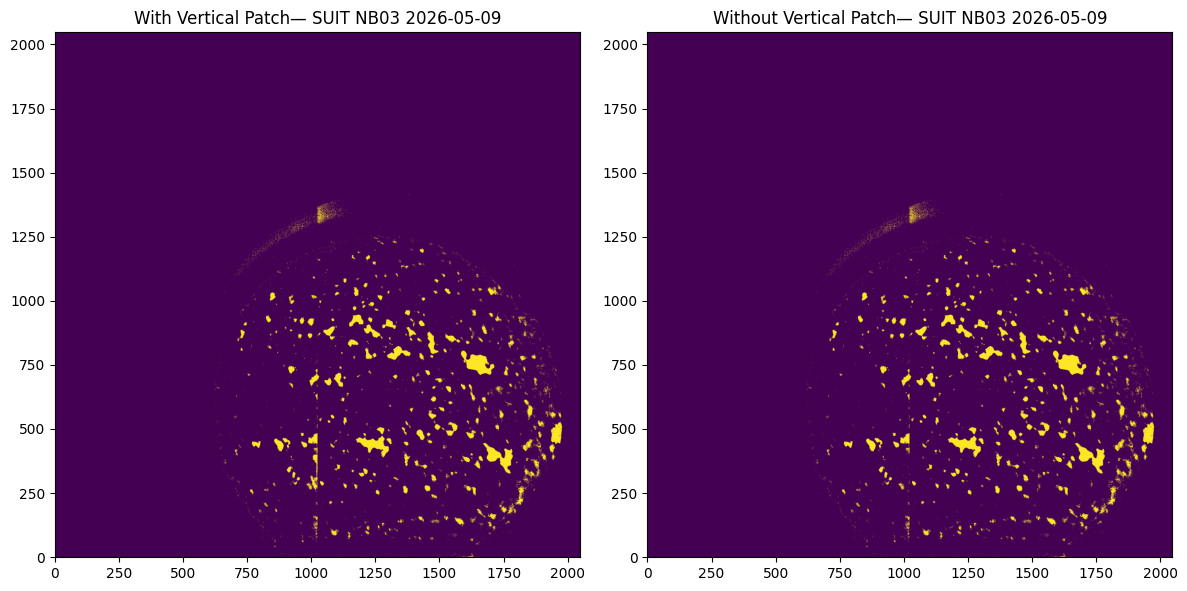

In [13]:
ver_blob_mask = (labeled_2 == p)
ver_blob_removed = (hor_blob_removed) & (~ver_blob_mask)

# Displaying graphs side by side for omparison: 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(hor_blob_removed, origin='lower')
ax[0].set_title('With Vertical Patch— SUIT NB03 2026-05-09')
ax[1].imshow(ver_blob_removed, origin='lower')
ax[1].set_title('Without Vertical Patch— SUIT NB03 2026-05-09')

plt.tight_layout()
plt.show()

**We have successfully removed solar limb, horizontal patch and vertical patch**
## Minimizing off-disk artifact: 

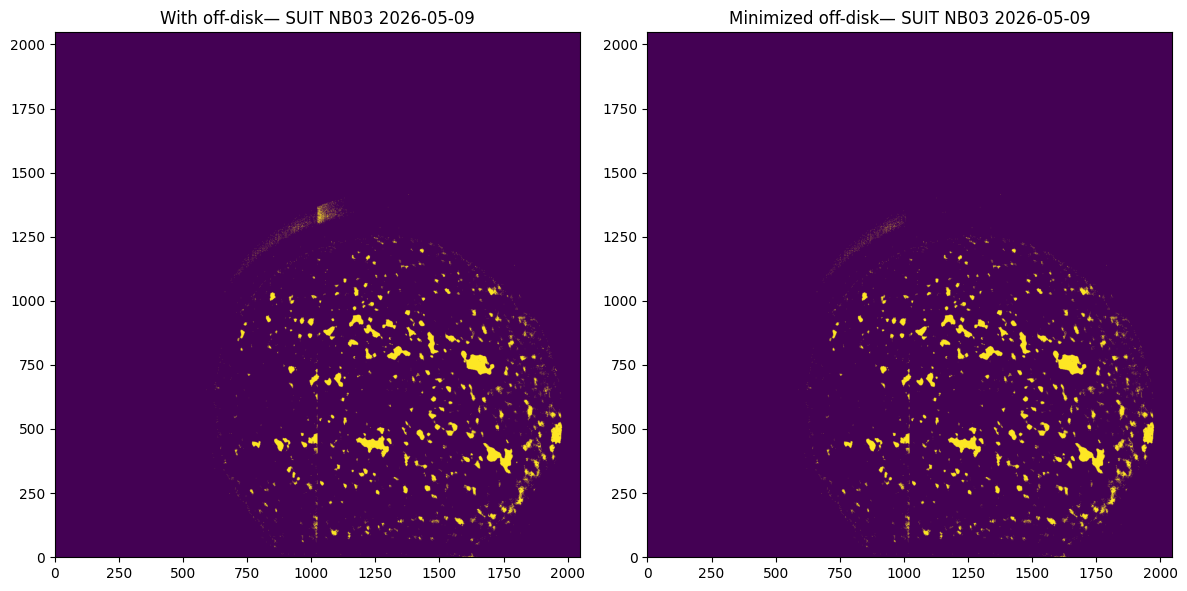

In [14]:
rows, cols = np.where(bright_cluster_mask[1290:1400, 1010:1150])  


off_disk_masked = np.zeros(bright_cluster_mask.shape, dtype=bool)  # Creating a new boolean array with same shape as active_region_mask and all values False. 
off_disk_masked[1290:1400, 1010:1150] = True       # Converting the False values to True for mentioned indices.
kmeans_final = (ver_blob_removed) & (~off_disk_masked)  # Creating a new array which contains all previous features except the off-disk blob.

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(ver_blob_removed, origin='lower')
ax[0].set_title('With off-disk— SUIT NB03 2026-05-09')
ax[1].imshow(kmeans_final, origin='lower')
ax[1].set_title('Minimized off-disk— SUIT NB03 2026-05-09')

plt.tight_layout()
plt.savefig(r'../Outputs/Figures/Part_2c/Fig.3_Final_MO_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**We have successfully minimized off-disk distortion without disturbing solar disk.**

In [15]:
labeled_kmeans = label(kmeans_final)
kmeans_regions = regionprops(labeled_kmeans)
print(len(kmeans_regions))

areas = sorted([r.area for r in kmeans_regions], reverse=True)
print(areas[:50])  # top 50 to get a sense of the distribution
print(areas[-50:])

print(f"Total blobs: {len(areas)}")
print(f"Blobs with area > 10: {sum(1 for a in areas if a > 10)}")
print(f"Blobs with area > 50: {sum(1 for a in areas if a > 50)}")
print(f"Blobs with area > 100: {sum(1 for a in areas if a > 100)}")

4368
[np.float64(6050.0), np.float64(5234.0), np.float64(4489.0), np.float64(2635.0), np.float64(2197.0), np.float64(1725.0), np.float64(1441.0), np.float64(1415.0), np.float64(1091.0), np.float64(1090.0), np.float64(1043.0), np.float64(1042.0), np.float64(1017.0), np.float64(976.0), np.float64(946.0), np.float64(892.0), np.float64(885.0), np.float64(807.0), np.float64(807.0), np.float64(790.0), np.float64(751.0), np.float64(689.0), np.float64(615.0), np.float64(607.0), np.float64(601.0), np.float64(565.0), np.float64(554.0), np.float64(532.0), np.float64(515.0), np.float64(511.0), np.float64(509.0), np.float64(494.0), np.float64(493.0), np.float64(481.0), np.float64(460.0), np.float64(447.0), np.float64(446.0), np.float64(425.0), np.float64(422.0), np.float64(398.0), np.float64(394.0), np.float64(387.0), np.float64(387.0), np.float64(383.0), np.float64(376.0), np.float64(371.0), np.float64(360.0), np.float64(359.0), np.float64(349.0), np.float64(345.0)]
[np.float64(1.0), np.float64(1.

After Otsu thresholding, **61** blobs were identified as active regions but, here as we can see that K-means clustering has identified **4368** blobs as active regions. This seems counterintuitive first, as the threshold value from Otsu's algorithm was **0.5341** and **0.63** for k-means clustering thus indicating the detection of less than 61 blobs. But, this indiscrepancy is because K-means assigns each pixel independently to the nearest cluster center- there is no concept of spatial connectivity. It means that we get many isolated single pixels or small groups, each counted as one blob.

Many of these blobs are just a few pixels in size which means that they are noise from k-means pixel-level clustering. So, we would have to remove these noisy results before we proceed. From above cell, we can see there are **159** blobs having area greater than 100, this seems a fine minimim threshold area (as Otsu identified 61 blobs, these 2 numbers are much more comparable than 4368 vs 61).

In [16]:
min_area = 100
kmeans_filtered = [r for r in kmeans_regions if r.area > min_area]  # array with noise removed.

## External Data Validation:

In [17]:
tstart = '2026/05/09 01:09:21'
tend = '2026/05/09 13:09:21'
event_type = 'AR'    # Active Regions
result = Fido.search(a.Time(tstart,tend), a.hek.EventType(event_type))
print("A look at the data:")
print(result[:10])
print(len(result[0]))

# Columns of Interest: hgs_coord and ar_noaanum


A look at the data:
Results from 1 Provider:

68 Results from the HEKClient:

                                                            gs_thumburl                                                             comment_count                              hpc_bbox                                meanphotoenergydensity  frm_humanflag           hgc_coord           ar_spotarearepruncert obs_levelnum                hpc_coord                event_npixels                                                            gs_imageurl                                                             ar_polarity                                                                                                                                                                                                                                                                              frm_paramset                                                                                                                              

In [18]:
from skimage import measure
# We are trying to convert image pixels to Stonyhurst coordinates.
cleaned_labeled = label(kmeans_final)
regions = measure.regionprops(cleaned_labeled)
for i in regions:
    print(i.centroid)  # NOTE: here output is in (row,col) format, pixel_to_world uses (col,row) format.

#suit_map = smap

(np.float64(0.2857142857142857), np.float64(1591.4285714285713))
(np.float64(0.6666666666666666), np.float64(1596.3333333333333))
(np.float64(0.5), np.float64(1600.75))
(np.float64(0.0), np.float64(1604.5))
(np.float64(0.3333333333333333), np.float64(1608.0))
(np.float64(1.3125), np.float64(1615.0625))
(np.float64(0.0), np.float64(1618.0))
(np.float64(2.5405405405405403), np.float64(1625.945945945946))
(np.float64(0.3333333333333333), np.float64(1632.3333333333333))
(np.float64(0.0), np.float64(1645.0))
(np.float64(1.0), np.float64(1635.0))
(np.float64(2.0), np.float64(1593.0))
(np.float64(2.0), np.float64(1620.0))
(np.float64(3.0), np.float64(1578.0))
(np.float64(3.0), np.float64(1587.0))
(np.float64(5.0), np.float64(1547.0))
(np.float64(5.333333333333333), np.float64(1577.0))
(np.float64(5.0), np.float64(1621.0))
(np.float64(6.0), np.float64(1493.0))
(np.float64(6.0), np.float64(1552.0))
(np.float64(6.0), np.float64(1554.0))
(np.float64(6.0), np.float64(1597.0))
(np.float64(8.0), np.

In [19]:
print(result[0].colnames)

['gs_thumburl', 'comment_count', 'hpc_bbox', 'meanphotoenergydensity', 'frm_humanflag', 'hgc_coord', 'ar_spotarearepruncert', 'obs_levelnum', 'hpc_coord', 'event_npixels', 'gs_imageurl', 'ar_polarity', 'frm_paramset', 'hrc_coord', 'event_starttime', 'ar_mtwilsoncls', 'event_type', 'meantwistalpha', 'intensmin', 'obs_meanwavel', 'frm_url', 'bound_chaincode', 'totalphotoenergy', 'noposition', 'ar_spotarearepr', 'active', 'intensmax', 'frm_versionnumber', 'ar_pilcurvature', 'area_uncert', 'obs_dataprepurl', 'hpc_geom', 'hgc_bbox', 'intensmedian', 'chaincodetype', 'obs_channelid', 'event_clippedspatial', 'ar_noaaclass', 'SOL_standard', 'event_avg_rating', 'eventtype', 'hpc_boundcc', 'event_mapurl', 'frm_contact', 'meanvertcurrentdensity', 'ar_penumbracls', 'intensmean', 'bound_ccstartc1', 'frm_name', 'area_atdiskcenter', 'frm_identifier', 'obs_observatory', 'event_description', 'ar_spotarearaw', 'unsignedflux', 'boundbox_c2ur', 'highshearareapercent', 'obs_firstprocessingdate', 'sharp_noaa

In [20]:
verified_regions = []
noaa_catalog = result[0][result[0]['ar_noaanum'].filled(0) != 0]
for i in kmeans_filtered:
    x,y = i.centroid  # gives (row,col) form of centroids
    hpc_coord = suit_map.pixel_to_world(y * u.pixel, x * u.pixel)  #converting pixel coordinates to helioprojective coordinates
    hgs_coord = hpc_coord.transform_to(HeliographicStonyhurst)   # converting helioprojective coords to heliographic stonyhurst
    catalog_comparison = hgs_coord.separation(noaa_catalog['hgs_coord'])    # comparing the two coordinates, ie Aditya L1's and NOAA's.
    best_match_idx = np.argmin(catalog_comparison)
    if np.any(catalog_comparison <= 5 * u.deg):
        print(f'My region {i.label} matched with NOAA AR{noaa_catalog['ar_noaanum'][best_match_idx]} with a separation of {catalog_comparison[best_match_idx]} degrees.')
        verified_regions.append((i.label, noaa_catalog['ar_noaanum'][best_match_idx]))
print(verified_regions)    

 '2026-05-09T00:00:00.000' '2026-05-09T00:00:00.000'
 '2026-05-09T00:00:00.000' '2026-05-09T00:00:00.000'
 '2026-05-09T00:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000'], rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-09T07:09:21.400, rsun=695700.0 km)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]
2026-08-04 16:11:08 - astropy - WARNING: NonRotationTransformationWarning: transforming other coordinates from <HeliographicStonyhurst Frame (obstime=['2026-05-09T00:00:00.000' '20

My region 1110 matched with NOAA AR14431 with a separation of 0.8997121552220548 deg degrees.


2026-08-04 16:11:09 - sunpy - WARNING: SunpyUserWarning: The conversion of these 2D helioprojective coordinates to 3D is all NaNs because off-disk coordinates need an additional assumption to be mapped to calculate distance from the observer. Consider using the context manager `SphericalScreen()`.


My region 1198 matched with NOAA AR14431 with a separation of 4.977721958369564 deg degrees.
My region 1260 matched with NOAA AR14433 with a separation of 0.3218707418259183 deg degrees.


d:\My Folder\ISA\Project work\AdityaL1_ISA\Lib\site-packages\astropy\utils\masked\core.py:1119: RuntimeWarning: All-NaN slice encountered
  kwargs["initial"] = initial_func(self.unmasked)


My region 1399 matched with NOAA AR14433 with a separation of 1.7369009858099154 deg degrees.
My region 2285 matched with NOAA AR14432 with a separation of 0.45835651293862056 deg degrees.
My region 2464 matched with NOAA AR14434 with a separation of 4.429750844281132 deg degrees.
My region 2467 matched with NOAA AR14434 with a separation of 0.9855339389859984 deg degrees.
My region 2702 matched with NOAA AR14435 with a separation of 2.5082879009856116 deg degrees.
My region 2887 matched with NOAA AR14435 with a separation of 1.3482283667172448 deg degrees.
My region 2941 matched with NOAA AR14435 with a separation of 1.930878673261476 deg degrees.
[(1110, np.int32(14431)), (1198, np.int32(14431)), (1260, np.int32(14433)), (1399, np.int32(14433)), (2285, np.int32(14432)), (2464, np.int32(14434)), (2467, np.int32(14434)), (2702, np.int32(14435)), (2887, np.int32(14435)), (2941, np.int32(14435))]


In [21]:
# Finding the unique regions: 
unique_noaa = set([t[1] for t in verified_regions])
print(f"Unique NOAA ARs matched: {unique_noaa}")
print(f"Total verified blobs: {len(verified_regions)}")

Unique NOAA ARs matched: {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14431)}
Total verified blobs: 10


## K-means Contour Overlay:

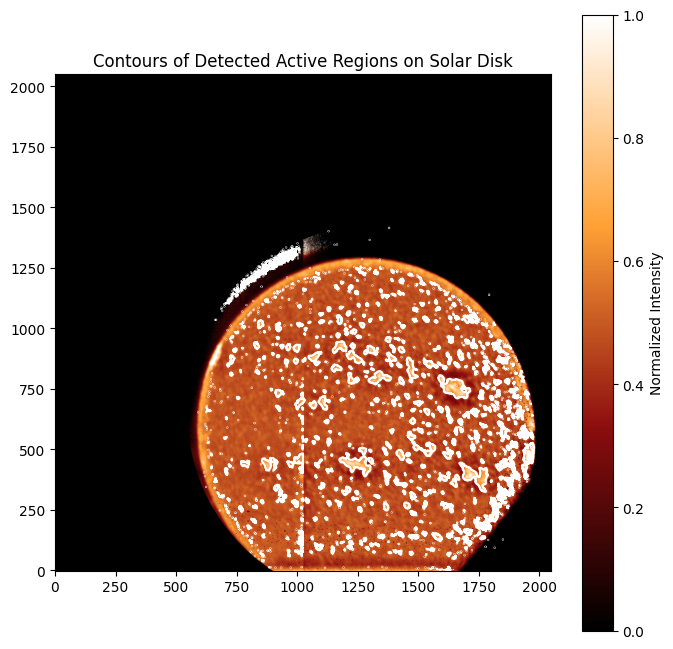

In [22]:
cmap = suit_cmap('NB03')
plt.figure(figsize=(8,8))
plt.imshow(arr_2d_masked, origin='lower', cmap=cmap)
plt.colorbar(label= 'Normalized Intensity')
plt.contour(kmeans_final, origin='lower', colors='white')
plt.title('Contours of Detected Active Regions on Solar Disk')
plt.savefig(r'../Outputs/Figures/Part_2c/Fig.4_K-Means_Contour_Image.png', dpi=150, bbox_inches='tight')
plt.show()

## Visual Comparison b/w Otsu and K-means:

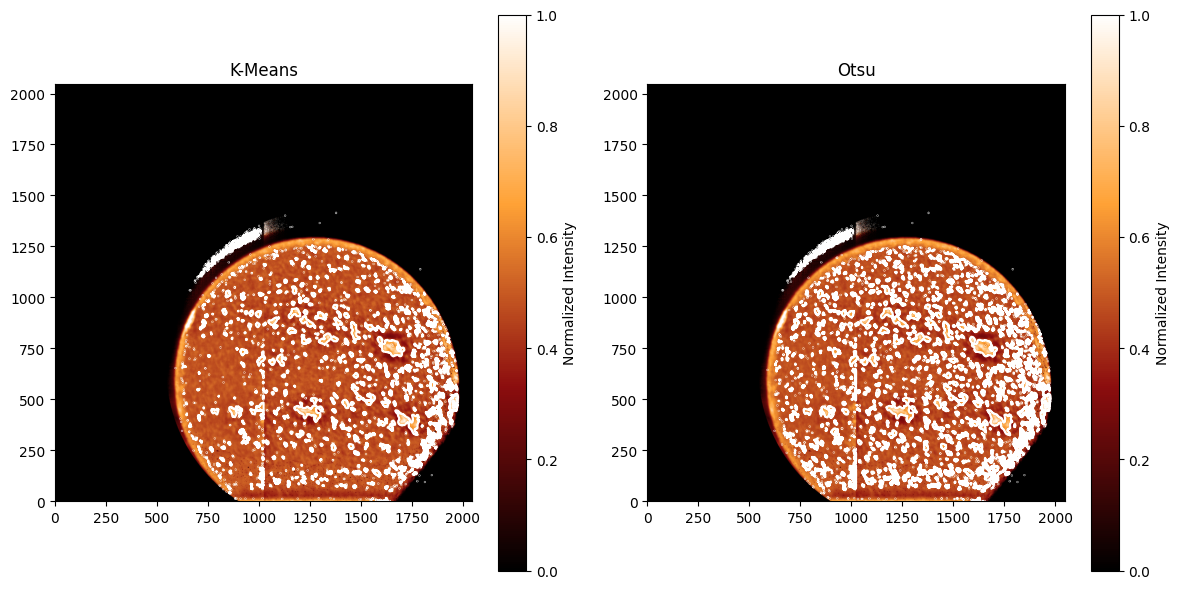

In [23]:
off_disk_removed = np.load(r"..\Data\Processed\off_disk_removed.npy")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
cmap = suit_cmap('NB03')   # false colormap for NB03 filter.
im = ax[0].imshow(arr_2d_masked, cmap=cmap, origin='lower')    # arr_2d_masked is our disk-masked, flat field corrected and normalised array.
ax[0].contour(kmeans_final, origin='lower', colors='white')   # applying contour from the final array off_disk_removed.
ax[0].set_title('K-Means')
fig.colorbar(im, ax=ax[0], label='Normalized Intensity')
ax[1].imshow(arr_2d_masked, origin='lower', cmap=cmap)
ax[1].contour(off_disk_removed, origin='lower', colors='white')
ax[1].set_title('Otsu')
fig.colorbar(im, ax=ax[1], label='Normalized Intensity')

plt.tight_layout()
plt.savefig(r'../Outputs/Figures/Part_2c/Fig.5_Otsu_vs_K-Means_Image.png', dpi=150, bbox_inches='tight')
plt.show()

## Observations: 

Both methods were applied to the same preprocessed array (arr_2d_masked) to ensure a valid comparison. Otsu thresholding detected 61 blobs matching 7 unique NOAA active regions, while k-means clustering (k=3, min_area=100) detected 159 blobs matching 5 unique NOAA active regions.

Visually, Otsu contours appear more densely distributed across the disk despite fewer total blobs, suggesting greater spatial spread of detections. K-means contours, though more numerous, are concentrated around higher-intensity features due to its elevated effective threshold (0.63 vs Otsu's 0.5341). Both methods show strong agreement in the eastern hemisphere, while significant differences appear in the western hemisphere where weaker active regions exist.

K-means missed 2 NOAA ARs compared to Otsu for two reasons: first, its higher intensity threshold caused weaker active regions (intensity 0.53–0.63) to be assigned to the quiet sun cluster; second, greater pixel-level fragmentation caused some active regions to be broken into sub-threshold blobs eliminated by the min_area=100 filter.